<h1>Titanic</h1>

In [ ]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request


def load_housing_data():
    tarball_path = Path("datasets/titanic.tgz")
    if not (tarball_path.is_file()):
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/titanic.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")

    return pd.read_csv(Path("datasets/titanic/test.csv")), pd.read_csv(Path("datasets/titanic/train.csv"))


test_data, train_data = load_housing_data()

In [ ]:
# train_data = train_data.set_index("PassengerId")
# test_data = test_data.set_index("PassengerId")

In [ ]:
from sklearn.model_selection import train_test_split

train_data_strat, test_data_strat = train_test_split(train_data, test_size=0.2, random_state=42, stratify=train_data["Pclass"])

In [ ]:
X_train = train_data_strat.drop("Survived",axis=1)
y_train = train_data_strat["Survived"]


In [ ]:
train_data['Embarked'] = train_data['Embarked'].fillna('S')
train_data['Cabin'] = train_data['Cabin'].fillna('None')
train_data

In [ ]:
import matplotlib.pyplot as plt

train_data.plot(
    kind="scatter",
    x="PassengerId",
    y="Age",
    # grid=True,
    s=(train_data["Parch"] * 5),
    c="Survived",
    cmap="jet",
    colorbar=True,
    legend=True,
    figsize=(7, 7),
)

plt.show()

In [151]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,None,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,None,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,None,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,None,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen 'Carrie'",female,NaN,1,2,W./C. 6607,23.4500,None,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [201]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_pipeline = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        ("Scale", StandardScaler()),
    ]
)

cat_pipeline = Pipeline(
    [
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

In [292]:
from sklearn.preprocessing import FunctionTransformer

def familysize(X):

    sibsp = X.iloc[:, 0]
    parch = X.iloc[:, 1]
    family = sibsp + parch + 1

    return family.values.reshape(-1, 1)


def title(X):
    names = X.iloc[:, 0]

    titles = names.str.extract(r" ([a-zA-Z]+)\.", expand=False)
    titles = titles.apply(lambda x: x if x in ["Mr", "Mrs", "Master", "Miss", "Mlle", "Ms", "Mme"] else 'Other')
    return titles.values.reshape(-1, 1)


family_transformer = FunctionTransformer(
    familysize, feature_names_out=lambda tf, names_in: ["family_size"]
)

title_transformer = FunctionTransformer(
    title, feature_names_out=lambda tf, names_in: ["title"]
)

In [309]:
from sklearn.compose import ColumnTransformer

num_attribs = ["Pclass", "Age", "Fare"]
cat_attribs = ["Sex", "Embarked"]

title_pipeline = Pipeline(
    [
        ("extract", title_transformer),
        ("encode", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessing = ColumnTransformer(
    [
        # ("title", title_pipeline, ["Name"]),
        ("cat", cat_pipeline, cat_attribs),
        ("fam", family_transformer, ["SibSp", "Parch"]),
        ("num", num_pipeline, num_attribs),
    ]
)

train_prepared = preprocessing.fit_transform(X_train, y_train)
pd.DataFrame(train_prepared, columns=preprocessing.get_feature_names_out())

,cat__Sex_female,cat__Sex_male,cat__Embarked_C,cat__Embarked_Q,cat__Embarked_S,fam__family_size,num__Pclass,num__Age,num__Fare
0,1.0,0.0,0.0,0.0,1.0,3.0,-1.564057,1.768064,1.259243
1,0.0,1.0,0.0,0.0,1.0,1.0,-0.367914,0.147312,-0.447327
2,0.0,1.0,0.0,0.0,1.0,1.0,0.828228,-0.161403,-0.485108
3,0.0,1.0,0.0,0.0,1.0,2.0,0.828228,-0.084224,-0.337326
4,0.0,1.0,0.0,0.0,1.0,1.0,-0.367914,-0.315760,-0.395925
...,...,...,...,...,...,...,...,...,...
707,0.0,1.0,0.0,0.0,1.0,7.0,0.828228,0.764741,-0.020171
708,0.0,1.0,1.0,0.0,0.0,1.0,-1.564057,1.304992,0.965219
709,0.0,1.0,0.0,0.0,1.0,1.0,0.828228,-0.624475,-0.502842
710,0.0,1.0,0.0,0.0,1.0,1.0,-1.564057,2.462672,0.001332


Data insights:
<ul>
    <li>Higher siblings/parents on board --> less chance</li>
    <li>Higher fare --> higher chance</li>
    <li>Q-> certain death, C -> higher chance of survival</li>
</ul>

Classifiers: KNN, SGD, RandomForest

In [310]:
# trying knn

from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = make_pipeline(preprocessing, KNeighborsClassifier())
# knn_pipeline

In [311]:
from sklearn.model_selection import GridSearchCV

knn_param = {
    "kneighborsclassifier__n_neighbors": [8, 9, 10, 11, 15, 20],
    "kneighborsclassifier__weights": ["uniform", "distance"],
    "kneighborsclassifier__p": [1, 2, 3, 4, 5],
}

gridSearch = GridSearchCV(knn_pipeline, param_grid=knn_param, cv=5)
gridSearch.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'kneighborsclassifier__n_neighbors': [8, 9, ...], 'kneighborsclassifier__p': [1, 2, ...], 'kneighborsclassifier__weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...), ('fam', ...), ...]"


In [312]:
print(f"Best score: {gridSearch.best_score_}")
print(f"Best params: {gridSearch.best_params_}")

best_knn = gridSearch.best_estimator_

Best score: 0.8300403821530582
Best params: {'kneighborsclassifier__n_neighbors': 8, 'kneighborsclassifier__p': 1, 'kneighborsclassifier__weights': 'uniform'}


In [313]:
from sklearn.model_selection import cross_val_score, cross_val_predict

score = cross_val_score(best_knn, X_train, y_train, cv=10)
score

array([0.79166667, 0.83333333, 0.85915493, 0.84507042, 0.90140845,
       0.92957746, 0.77464789, 0.77464789, 0.77464789, 0.73239437])

In [314]:
from sklearn.metrics import roc_curve

def plot_ROC(fpr, tpr):

    plt.plot(fpr, tpr, linewidth=2, label="ROC Curve")
    plt.plot([0, 1], [0, 1], "k:", label="Random classifier's ROC curve")

    plt.axis([0, 1, 0, 1])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid()
    plt.legend(loc="lower right")

# y_scores = cross_val_predict(
#     best_knn, X_train, y_train, cv=10, method="decision_function"
# )
# fpr_knn, tpr_knn, threshold = roc_curve(y_train, y_scores)

# plot_ROC(fpr_knn, tpr_knn)

In [315]:
#trying sgd

from sklearn.linear_model import SGDClassifier

sgd_pipeline = make_pipeline(preprocessing, SGDClassifier())
# sgd_pipeline


In [316]:
sgd_params = {
    "sgdclassifier__loss": ["hinge", "log_loss"],
    "sgdclassifier__penalty": ["l2", "elasticnet"],
    "sgdclassifier__alpha": [1e-4, 1e-3, 1e-2, 1e-1],
    "sgdclassifier__learning_rate": ["optimal", "adaptive"],
    "sgdclassifier__eta0": [0.01, 0.1],  # Required for adaptive rate
}

gridSearch = GridSearchCV(sgd_pipeline, param_grid=sgd_params, cv=10)
gridSearch.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'sgdclassifier__alpha': [0.0001, 0.001, ...], 'sgdclassifier__eta0': [0.01, 0.1], 'sgdclassifier__learning_rate': ['optimal', 'adaptive'], 'sgdclassifier__loss': ['hinge', 'log_loss'], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...), ('fam', ...), ...]"


In [317]:
print(f"Best score: {gridSearch.best_score_}")
print(f"Best params: {gridSearch.best_params_}")

best_sgd = gridSearch.best_estimator_

Best score: 0.8090179968701096
Best params: {'sgdclassifier__alpha': 0.1, 'sgdclassifier__eta0': 0.01, 'sgdclassifier__learning_rate': 'adaptive', 'sgdclassifier__loss': 'log_loss', 'sgdclassifier__penalty': 'l2'}


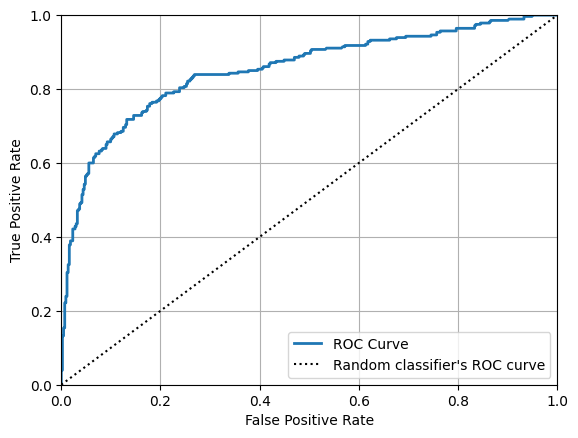

In [318]:
y_scores_sgd = cross_val_predict(
    best_sgd, X_train, y_train, cv=10, method="decision_function"
)
fpr_sgd, tpr_sgd, threshold = roc_curve(y_train, y_scores_sgd)

plot_ROC(fpr_sgd, tpr_sgd)
# plot_ROC(fpr_knn, tpr_knn)

In [319]:
from sklearn.ensemble import RandomForestClassifier

forest_pipeline = make_pipeline(preprocessing, RandomForestClassifier(random_state=42))
forest_pipeline

,steps,"[('columntransformer', ...), ('randomforestclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('fam', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [320]:
forest_params = {
    'randomforestclassifier__n_estimators': [100, 200, 500],       # Number of trees
    'randomforestclassifier__max_depth': [None, 5, 10, 15],         # Depth of trees
    'randomforestclassifier__min_samples_split': [2, 5, 10],        # Min samples to split a node
    'randomforestclassifier__min_samples_leaf': [1, 2, 4],          # Min samples at a leaf node
}

gridSearch = GridSearchCV(forest_pipeline, param_grid=forest_params, cv=3)
gridSearch.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'randomforestclassifier__max_depth': [None, 5, ...], 'randomforestclassifier__min_samples_leaf': [1, 2, ...], 'randomforestclassifier__min_samples_split': [2, 5, ...], 'randomforestclassifier__n_estimators': [100, 200, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...), ('fam', ...), ...]"


In [321]:
print(f"Best score: {gridSearch.best_score_}")
print(f"Best params: {gridSearch.best_params_}")

best_forest = gridSearch.best_estimator_
best_features = best_forest.named_steps['randomforestclassifier'].feature_importances_
pd.DataFrame(best_features, index=preprocessing.get_feature_names_out()).sort_index()

Best score: 0.8455010696261627
Best params: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 2, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 500}


,0
cat__Embarked_C,0.011833
cat__Embarked_Q,0.006366
cat__Embarked_S,0.013542
cat__Sex_female,0.198703
cat__Sex_male,0.207927
fam__family_size,0.096232
num__Age,0.174470
num__Fare,0.198786
num__Pclass,0.092141


In [322]:
X_test = test_data_strat.drop("Survived",axis=1)
y_test = test_data_strat["Survived"]

In [323]:
best_forest.score(X_test, y_test)

0.7988826815642458